<a href="https://colab.research.google.com/github/Rini43/Case_Study/blob/main/Case_Study_NLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [122]:
!pip install gensim

# Libraries

In [213]:
# Basic Libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Text Processing
import re
import string

# Import NLTK library
import nltk

# Import stopwords
from nltk.corpus import stopwords

# Import the Porter Stemmer for word stemming
from nltk.stem import PorterStemmer

# Import the WordNet Lemmatizer for converting words to their base form
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import CountVectorizer

# Train-Test Split
from sklearn.model_selection import train_test_split

# TF-IDF Vectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

import gensim.downloader as api
from gensim.models import Word2Vec
from tqdm import tqdm

# Import Machine Learning Libraries
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.model_selection import GridSearchCV

from sklearn.metrics import (accuracy_score,
    precision_score, recall_score, f1_score,
    confusion_matrix, classification_report)
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import precision_recall_curve, average_precision_score

# Import Deep Learning Libraries
import tensorflow as tf
from tensorflow.keras.layers import (Input, Dense, Dropout,
    BatchNormalization, Concatenate, LeakyReLU)
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import (EarlyStopping, ReduceLROnPlateau)

# Read the Data

In [124]:
filepath = "/content/drive/MyDrive/Data/donor.csv"
df_donor = pd.read_csv(filepath)
df_donor.head(5)

,id,teacher_prefix,school_state,project_grade_category,project_subject_categories,project_subject_subcategories,teacher_number_of_previously_posted_projects,project_is_approved,price,quantity,cleaned_titles,cleaned_essays,cleaned_summary,isdigit_summary
0,p253737,mrs,in,grades_prek_2,literacy_language,esl_literacy,0,0,154.60,23,educational support english learners home,students english learners working english seco...,students_need_opportunities_practice_beginning...,0
1,p258326,mr,fl,grades_6_8,history_civics_health_sports,civics_government_teamsports,7,1,299.00,1,wanted projector hungry learners,students arrive school eager learn polite gene...,students_need_projector_help_viewing_education...,0
2,p182444,ms,az,grades_6_8,health_sports,health_wellness_teamsports,1,0,516.85,22,soccer equipment awesome middle school students,true champions not always ones win guts mia ha...,students_need_shine_guards_athletic_socks_socc...,0
3,p246581,mrs,ky,grades_prek_2,literacy_language_math_science,literacy_mathematics,4,1,232.90,4,techie kindergarteners,work unique school filled esl english second l...,students_need_engage_reading_math_way_inspire_...,0
4,p104768,mrs,tx,grades_prek_2,math_science,mathematics,1,1,67.98,4,interactive math tools,second grade classroom next year made around 2...,students_need_hands_practice_mathematics_fun_p...,0


# Exploratory Data Analysis

In [125]:
# Dataset Information

df_donor.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109248 entries, 0 to 109247
Data columns (total 14 columns):
 #   Column                                        Non-Null Count   Dtype  
---  ------                                        --------------   -----  
 0   id                                            109248 non-null  object 
 1   teacher_prefix                                109248 non-null  object 
 2   school_state                                  109248 non-null  object 
 3   project_grade_category                        109248 non-null  object 
 4   project_subject_categories                    109248 non-null  object 
 5   project_subject_subcategories                 109248 non-null  object 
 6   teacher_number_of_previously_posted_projects  109248 non-null  int64  
 7   project_is_approved                           109248 non-null  int64  
 8   price                                         109248 non-null  float64
 9   quantity                                      10

In [126]:
# Statistical Summary

df_donor.describe()

,teacher_number_of_previously_posted_projects,project_is_approved,price,quantity,isdigit_summary
count,109248.000000,109248.000000,109248.000000,109248.000000,109248.000000
mean,11.153165,0.848583,298.119343,16.965610,0.144222
std,27.777154,0.358456,367.498030,26.182942,0.351317
min,0.000000,0.000000,0.660000,1.000000,0.000000
25%,0.000000,1.000000,104.310000,4.000000,0.000000
50%,2.000000,1.000000,206.220000,9.000000,0.000000
75%,9.000000,1.000000,379.000000,21.000000,0.000000
max,451.000000,1.000000,9999.000000,930.000000,1.000000


In [127]:
# Shape of Dataset

print("Rows :", df_donor.shape[0])
print("Columns :", df_donor.shape[1])

Rows : 109248
Columns : 14


In [128]:
# Missing Values

df_donor.isnull().sum()

,0
id,0
teacher_prefix,0
school_state,0
project_grade_category,0
project_subject_categories,0
project_subject_subcategories,0
teacher_number_of_previously_posted_projects,0
project_is_approved,0
price,0
quantity,0


In [129]:
# Handling the missing value

df_donor['cleaned_titles'] = df_donor['cleaned_titles'].fillna('')

In [130]:
# After handling the missing value

df_donor['cleaned_titles'].isnull().sum()

np.int64(0)

In [131]:
# Duplicate Rows

df_donor.duplicated().sum()

np.int64(0)

In [132]:
# Drop the column id

df_donor = df_donor.drop(columns=['id'])

In [133]:
# Target Variable Analysis

df_donor["project_is_approved"].value_counts()

,count
project_is_approved,
1,92706
0,16542


In [134]:
# Define the categorical and numerical columns

categorical_cols = df_donor.select_dtypes(include='object').columns

numerical_cols = df_donor.select_dtypes(exclude='object').columns

print("Categorical Columns\n")
print(categorical_cols)

print("\nNumerical Columns\n")
print(numerical_cols)

Categorical Columns

Index(['teacher_prefix', 'school_state', 'project_grade_category',
       'project_subject_categories', 'project_subject_subcategories',
       'cleaned_titles', 'cleaned_essays', 'cleaned_summary'],
      dtype='object')

Numerical Columns

Index(['teacher_number_of_previously_posted_projects', 'project_is_approved',
       'price', 'quantity', 'isdigit_summary'],
      dtype='object')


In [135]:
# Number of unique values

df_donor['project_subject_categories'].nunique()

51

In [136]:
# Unique values

df_donor['project_grade_category'].unique()

array(['grades_prek_2', 'grades_6_8', 'grades_3_5', 'grades_9_12'],
      dtype=object)

In [137]:
df_donor['project_subject_subcategories'].nunique()

401

# NLP Preprocessing

In [138]:
# Download required NLTK datasets

nltk.download('punkt')        # Sentence and word tokenizer
nltk.download('punkt_tab')
nltk.download('stopwords')    # Common stopwords (e.g., "the", "is", "and")
nltk.download('wordnet')      # WordNet lexical database for lemmatization

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

## Punctuations

In [139]:
# Select all object (string) columns

text_columns = df_donor.select_dtypes(include='object').columns

for col in text_columns:
    if col == 'cleaned_summary':
        continue

    df_donor[col] = df_donor[col].str.translate(
        str.maketrans('', '', string.punctuation)
    )

df_donor.head()

,teacher_prefix,school_state,project_grade_category,project_subject_categories,project_subject_subcategories,teacher_number_of_previously_posted_projects,project_is_approved,price,quantity,cleaned_titles,cleaned_essays,cleaned_summary,isdigit_summary
0,mrs,in,gradesprek2,literacylanguage,eslliteracy,0,0,154.60,23,educational support english learners home,students english learners working english seco...,students_need_opportunities_practice_beginning...,0
1,mr,fl,grades68,historycivicshealthsports,civicsgovernmentteamsports,7,1,299.00,1,wanted projector hungry learners,students arrive school eager learn polite gene...,students_need_projector_help_viewing_education...,0
2,ms,az,grades68,healthsports,healthwellnessteamsports,1,0,516.85,22,soccer equipment awesome middle school students,true champions not always ones win guts mia ha...,students_need_shine_guards_athletic_socks_socc...,0
3,mrs,ky,gradesprek2,literacylanguagemathscience,literacymathematics,4,1,232.90,4,techie kindergarteners,work unique school filled esl english second l...,students_need_engage_reading_math_way_inspire_...,0
4,mrs,tx,gradesprek2,mathscience,mathematics,1,1,67.98,4,interactive math tools,second grade classroom next year made around 2...,students_need_hands_practice_mathematics_fun_p...,0


# HTML tags

In [140]:
# Checking for HTML tags

# Find object (text) columns
text_columns = df_donor.select_dtypes(include='object').columns

for col in text_columns:
    html_count = df_donor[col].astype(str).str.contains(r'<[^>]+>', regex=True, na=False).sum()
    print(f"{col}: {html_count} rows contain HTML tags")

teacher_prefix: 0 rows contain HTML tags
school_state: 0 rows contain HTML tags
project_grade_category: 0 rows contain HTML tags
project_subject_categories: 0 rows contain HTML tags
project_subject_subcategories: 0 rows contain HTML tags
cleaned_titles: 0 rows contain HTML tags
cleaned_essays: 0 rows contain HTML tags
cleaned_summary: 0 rows contain HTML tags


## Lowercase

In [141]:
# Checking if there is any Upper Case Values

text_columns = df_donor.select_dtypes(include='object').columns

for col in text_columns:
    has_uppercase = df_donor[col].astype(str).str.contains(r'[A-Z]', regex=True).any()
    print(f"{col}: {has_uppercase}")

# There is no Uppercase values so no need for this step

teacher_prefix: False
school_state: False
project_grade_category: False
project_subject_categories: False
project_subject_subcategories: False
cleaned_titles: False
cleaned_essays: False
cleaned_summary: False


## Numbers

In [142]:
# Checking for numbers

text_columns = df_donor.select_dtypes(include='object').columns

for col in text_columns:
    number_count = df_donor[col].astype(str).str.contains(r'\d', regex=True, na=False).sum()
    print(f"{col}: {number_count} rows contain numbers")

# Numbers were retained because they contain meaningful information.

# Replace all numbers with a special token, for reference

# for col in ['cleaned_titles', 'cleaned_essays', 'cleaned_summary']:
#    df_donor[col] = df_donor[col].astype(str).apply(
#        lambda x: re.sub(r'\d+', '<NUM>', x))

teacher_prefix: 0 rows contain numbers
school_state: 0 rows contain numbers
project_grade_category: 109248 rows contain numbers
project_subject_categories: 0 rows contain numbers
project_subject_subcategories: 0 rows contain numbers
cleaned_titles: 6354 rows contain numbers
cleaned_essays: 72106 rows contain numbers
cleaned_summary: 15756 rows contain numbers


## Special Character

In [143]:
# Checking for special characters

text_columns = df_donor.select_dtypes(include='object').columns

for col in text_columns:
    special_count = df_donor[col].astype(str).str.contains(r'[^A-Za-z0-9\s]', regex=True, na=False).sum()
    print(f"{col}: {special_count} rows contain special characters")

# Replace underscores with spaces

df_donor[col] = df_donor[col].str.replace('_', ' ', regex=False)

# The only special character used here is the '_' for space division for the words.

teacher_prefix: 0 rows contain special characters
school_state: 0 rows contain special characters
project_grade_category: 0 rows contain special characters
project_subject_categories: 0 rows contain special characters
project_subject_subcategories: 0 rows contain special characters
cleaned_titles: 0 rows contain special characters
cleaned_essays: 0 rows contain special characters
cleaned_summary: 109248 rows contain special characters


In [144]:
print(f"cleaned_summary: {special_count} rows contain special characters")

cleaned_summary: 109248 rows contain special characters


## Tokenziation

In [145]:
# Tokenize all text columns

text_columns = ['cleaned_titles', 'cleaned_essays', 'cleaned_summary']

for col in text_columns:

    # Replace underscores with spaces
    df_donor[col] = df_donor[col].str.replace('_', ' ', regex=False)

    # Tokenize
    df_donor[col.replace('cleaned_', '') + '_tokens'] = df_donor[col].apply(nltk.word_tokenize)

df_donor.head()

# These are fixed categories. There are only a few possible values. So there is no need to do tokenization for "project_grade_category"
# These are labels, not sentences. So there is no need to do tokenization for "project_subject_categories"
# These are labels, not sentences. So there is no need to do tokenization for "project_subject_subcategories"

,teacher_prefix,school_state,project_grade_category,project_subject_categories,project_subject_subcategories,teacher_number_of_previously_posted_projects,project_is_approved,price,quantity,cleaned_titles,cleaned_essays,cleaned_summary,isdigit_summary,titles_tokens,essays_tokens,summary_tokens
0,mrs,in,gradesprek2,literacylanguage,eslliteracy,0,0,154.60,23,educational support english learners home,students english learners working english seco...,students need opportunities practice beginning...,0,"[educational, support, english, learners, home]","[students, english, learners, working, english...","[students, need, opportunities, practice, begi..."
1,mr,fl,grades68,historycivicshealthsports,civicsgovernmentteamsports,7,1,299.00,1,wanted projector hungry learners,students arrive school eager learn polite gene...,students need projector help viewing education...,0,"[wanted, projector, hungry, learners]","[students, arrive, school, eager, learn, polit...","[students, need, projector, help, viewing, edu..."
2,ms,az,grades68,healthsports,healthwellnessteamsports,1,0,516.85,22,soccer equipment awesome middle school students,true champions not always ones win guts mia ha...,students need shine guards athletic socks socc...,0,"[soccer, equipment, awesome, middle, school, s...","[true, champions, not, always, ones, win, guts...","[students, need, shine, guards, athletic, sock..."
3,mrs,ky,gradesprek2,literacylanguagemathscience,literacymathematics,4,1,232.90,4,techie kindergarteners,work unique school filled esl english second l...,students need engage reading math way inspire ...,0,"[techie, kindergarteners]","[work, unique, school, filled, esl, english, s...","[students, need, engage, reading, math, way, i..."
4,mrs,tx,gradesprek2,mathscience,mathematics,1,1,67.98,4,interactive math tools,second grade classroom next year made around 2...,students need hands practice mathematics fun p...,0,"[interactive, math, tools]","[second, grade, classroom, next, year, made, a...","[students, need, hands, practice, mathematics,..."


## Stop Words Removal

In [146]:
stop_words = set(stopwords.words("english"))

for col in ["titles_tokens", "essays_tokens", "summary_tokens"]:
    df_donor[col] = df_donor[col].apply(
        lambda tokens: [word for word in tokens if word.lower() not in stop_words])

df_donor.head()

,teacher_prefix,school_state,project_grade_category,project_subject_categories,project_subject_subcategories,teacher_number_of_previously_posted_projects,project_is_approved,price,quantity,cleaned_titles,cleaned_essays,cleaned_summary,isdigit_summary,titles_tokens,essays_tokens,summary_tokens
0,mrs,in,gradesprek2,literacylanguage,eslliteracy,0,0,154.60,23,educational support english learners home,students english learners working english seco...,students need opportunities practice beginning...,0,"[educational, support, english, learners, home]","[students, english, learners, working, english...","[students, need, opportunities, practice, begi..."
1,mr,fl,grades68,historycivicshealthsports,civicsgovernmentteamsports,7,1,299.00,1,wanted projector hungry learners,students arrive school eager learn polite gene...,students need projector help viewing education...,0,"[wanted, projector, hungry, learners]","[students, arrive, school, eager, learn, polit...","[students, need, projector, help, viewing, edu..."
2,ms,az,grades68,healthsports,healthwellnessteamsports,1,0,516.85,22,soccer equipment awesome middle school students,true champions not always ones win guts mia ha...,students need shine guards athletic socks socc...,0,"[soccer, equipment, awesome, middle, school, s...","[true, champions, always, ones, win, guts, mia...","[students, need, shine, guards, athletic, sock..."
3,mrs,ky,gradesprek2,literacylanguagemathscience,literacymathematics,4,1,232.90,4,techie kindergarteners,work unique school filled esl english second l...,students need engage reading math way inspire ...,0,"[techie, kindergarteners]","[work, unique, school, filled, esl, english, s...","[students, need, engage, reading, math, way, i..."
4,mrs,tx,gradesprek2,mathscience,mathematics,1,1,67.98,4,interactive math tools,second grade classroom next year made around 2...,students need hands practice mathematics fun p...,0,"[interactive, math, tools]","[second, grade, classroom, next, year, made, a...","[students, need, hands, practice, mathematics,..."


* categorical variables, but they are actually text-like categorical features because they contain words or phrases
* These values are labels, not sentences.
* They contain very few words.
* They rarely include common stop words like "the", "is", "and", or "to".

## Stemming

In [147]:
# stemmer = PorterStemmer()

# Apply stemming

# for col in ["titles_tokens", "essays_tokens", "summary_tokens"]:
#    df_donor[col] = df_donor[col].apply(
#        lambda tokens: [stemmer.stem(word) for word in tokens])

# df_donor.head()

## Lemmatization

In [148]:
lemmatizer = WordNetLemmatizer()

# Apply lemmatization

for col in ["titles_tokens", "essays_tokens", "summary_tokens"]:
    df_donor[col] = df_donor[col].apply(
        lambda tokens: [lemmatizer.lemmatize(word) for word in tokens])

df_donor.head()

,teacher_prefix,school_state,project_grade_category,project_subject_categories,project_subject_subcategories,teacher_number_of_previously_posted_projects,project_is_approved,price,quantity,cleaned_titles,cleaned_essays,cleaned_summary,isdigit_summary,titles_tokens,essays_tokens,summary_tokens
0,mrs,in,gradesprek2,literacylanguage,eslliteracy,0,0,154.60,23,educational support english learners home,students english learners working english seco...,students need opportunities practice beginning...,0,"[educational, support, english, learner, home]","[student, english, learner, working, english, ...","[student, need, opportunity, practice, beginni..."
1,mr,fl,grades68,historycivicshealthsports,civicsgovernmentteamsports,7,1,299.00,1,wanted projector hungry learners,students arrive school eager learn polite gene...,students need projector help viewing education...,0,"[wanted, projector, hungry, learner]","[student, arrive, school, eager, learn, polite...","[student, need, projector, help, viewing, educ..."
2,ms,az,grades68,healthsports,healthwellnessteamsports,1,0,516.85,22,soccer equipment awesome middle school students,true champions not always ones win guts mia ha...,students need shine guards athletic socks socc...,0,"[soccer, equipment, awesome, middle, school, s...","[true, champion, always, one, win, gut, mia, h...","[student, need, shine, guard, athletic, sock, ..."
3,mrs,ky,gradesprek2,literacylanguagemathscience,literacymathematics,4,1,232.90,4,techie kindergarteners,work unique school filled esl english second l...,students need engage reading math way inspire ...,0,"[techie, kindergartener]","[work, unique, school, filled, esl, english, s...","[student, need, engage, reading, math, way, in..."
4,mrs,tx,gradesprek2,mathscience,mathematics,1,1,67.98,4,interactive math tools,second grade classroom next year made around 2...,students need hands practice mathematics fun p...,0,"[interactive, math, tool]","[second, grade, classroom, next, year, made, a...","[student, need, hand, practice, mathematics, f..."


# Classical Machine Learning Models

## Define Features and Target

In [149]:
# Create combined text

df_donor["combined_text"] = (
    df_donor["titles_tokens"].apply(lambda x: " ".join(x)) + " " +
    df_donor["essays_tokens"].apply(lambda x: " ".join(x)) + " " +
    df_donor["summary_tokens"].apply(lambda x: " ".join(x)))

In [150]:
# Define Independent and Target Variables

# Final cleaned text

X = df_donor["combined_text"]

# Target variable

y = df_donor["project_is_approved"]

### Train-Test Split

In [151]:
# Split Dataset into Training and Testing Sets

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20,
    random_state=42, stratify=y)

# The TF-IDF vectorizer learns the vocabulary from the training data.
# If we fit it on the entire dataset before splitting, information from the test set leaks into the model
# leading to overly best results.
# For example, seeing the questions before the exam.

In [152]:
# Verify the shapes

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (87398,)
X_test : (21850,)
y_train: (87398,)
y_test : (21850,)


# Text Vectorization

## Bag of Words

In [153]:
# Create Bag of Words (BoW)

bow = CountVectorizer(
    max_features=5000, ngram_range=(1,2),
    min_df=2,
    max_df=0.95)

# Convert text into sparse BoW matrix
X_train_bow = bow.fit_transform(X_train)
X_test_bow = bow.transform(X_test)

# Checking the Output

print("Training Shape :", X_train_bow.shape)
print("Testing Shape  :", X_test_bow.shape)

print("Vocabulary Size :", len(bow.vocabulary_))

# we are checking for the word counts

Training Shape : (87398, 5000)
Testing Shape  : (21850, 5000)
Vocabulary Size : 5000


In [154]:
# Get the vocabulary (feature names) learned by the vectorizer

feature_names = bow.get_feature_names_out()

# Display the first 30 feature names

print(feature_names[:30])

# Used to display the vocabulary (features) learned by the vectorizer.
# Retrieves all the unique words (or n-grams) that the vectorizer learned from your text data.
# These words become the features (columns) in the document-term matrix.

['000' '10' '10 year' '100' '100 free' '100 percent' '100 student' '11'
 '12' '12th' '13' '14' '15' '16' '17' '18' '19' '1st' '1st grade'
 '1st grader' '20' '20 student' '200' '2016' '2017' '21' '21st'
 '21st century' '22' '23']


In [155]:
# Evaluation Function

def evaluate_model(model, X_test, y_test):

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(y_test, y_pred,
        average="weighted")

    recall = recall_score(y_test, y_pred,
        average="weighted")

    f1 = f1_score(y_test, y_pred,
        average="weighted")

    print("Accuracy :", round(accuracy,4))
    print("Precision:", round(precision,4))
    print("Recall   :", round(recall,4))
    print("F1 Score :", round(f1,4))

    print("\nClassification Report\n")
    print(classification_report(y_test,y_pred))

    print("\nConfusion Matrix\n")
    print(confusion_matrix(y_test,y_pred))

    return accuracy, precision, recall, f1

In [156]:
# Creating Results List

results = []

In [157]:
# Train Logistic Regression

lr = LogisticRegression(
    max_iter=1000,
    random_state=42)

lr.fit(X_train_bow, y_train)

accuracy, precision, recall, f1 = evaluate_model(
    lr, X_test_bow, y_test)

results.append({
    "Embedding":"Bag of Words",
    "Model":"Logistic Regression",
    "Accuracy":accuracy,
    "Precision":precision,
    "Recall":recall,
    "F1 Score":f1})

Accuracy : 0.843
Precision: 0.7979
Recall   : 0.843
F1 Score : 0.8051

Classification Report

              precision    recall  f1-score   support

           0       0.44      0.13      0.20      3308
           1       0.86      0.97      0.91     18542

    accuracy                           0.84     21850
   macro avg       0.65      0.55      0.56     21850
weighted avg       0.80      0.84      0.81     21850


Confusion Matrix

[[  430  2878]
 [  552 17990]]


In [158]:
# Train SVM

svm = LinearSVC(random_state=42, max_iter=5000)

svm.fit(X_train_bow, y_train)

accuracy, precision, recall, f1 = evaluate_model(
    svm, X_test_bow, y_test)

results.append({
    "Embedding":"Bag of Words",
    "Model":"SVM",
    "Accuracy":accuracy,
    "Precision":precision,
    "Recall":recall,
    "F1 Score":f1})

Accuracy : 0.8476
Precision: 0.7986
Recall   : 0.8476
F1 Score : 0.7962

Classification Report

              precision    recall  f1-score   support

           0       0.48      0.07      0.12      3308
           1       0.86      0.99      0.92     18542

    accuracy                           0.85     21850
   macro avg       0.67      0.53      0.52     21850
weighted avg       0.80      0.85      0.80     21850


Confusion Matrix

[[  230  3078]
 [  252 18290]]


In [159]:
# Hyperparameter Tuning (Logistic Regression)

param_grid_lr = {
    "C": [0.01, 0.1, 1, 10],
    "solver": ["liblinear", "lbfgs"]}

grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid=param_grid_lr,
    cv=3,
    scoring="accuracy",
    n_jobs=-1)

grid_lr.fit(X_train_bow, y_train)

print("Best Parameters:", grid_lr.best_params_)
print("Best CV Accuracy:", grid_lr.best_score_)

Best Parameters: {'C': 0.01, 'solver': 'liblinear'}
Best CV Accuracy: 0.8494015803733874


In [160]:
# Best Tuned Model

best_lr = grid_lr.best_estimator_

# Prediction

y_pred_best_lr = best_lr.predict(X_test_bow)

accuracy, precision, recall, f1 = evaluate_model(best_lr, X_test_bow, y_test)

# Store Results

results.append({
    "Embedding": "Bag of Words",
    "Model": "Tuned Logistic Regression",
    "Accuracy": round(accuracy, 4),
    "Precision": round(precision, 4),
    "Recall": round(recall, 4),
    "F1 Score": round(f1, 4),
    "Best Parameters": str(grid_lr.best_params_),
    "CV Accuracy": round(grid_lr.best_score_, 4)})

Accuracy : 0.8492
Precision: 0.8044
Recall   : 0.8492
F1 Score : 0.7969

Classification Report

              precision    recall  f1-score   support

           0       0.51      0.07      0.12      3308
           1       0.86      0.99      0.92     18542

    accuracy                           0.85     21850
   macro avg       0.69      0.53      0.52     21850
weighted avg       0.80      0.85      0.80     21850


Confusion Matrix

[[  226  3082]
 [  213 18329]]


In [161]:
# Hyperparameter Tuning (SVM)

param_grid_svm = {
    "C": [0.1, 1, 10]}

grid_svm = GridSearchCV(LinearSVC(random_state=42),
    param_grid=param_grid_svm,
    cv=3,
    scoring="accuracy",
    n_jobs=-1)

grid_svm.fit(X_train_bow, y_train)

print(grid_svm.best_params_)
print(grid_svm.best_score_)

{'C': 0.1}
0.8426737392002543


In [162]:
# Best SVM Model

best_svm = grid_svm.best_estimator_

y_pred_best_svm = best_svm.predict(X_test_bow)

accuracy, precision, recall, f1 = evaluate_model(best_svm, X_test_bow, y_test)

# Store Results
results.append({
    "Embedding": "Bag of Words",
    "Model": "Tuned SVM",
    "Accuracy": round(accuracy, 4),
    "Precision": round(precision, 4),
    "Recall": round(recall, 4),
    "F1 Score": round(f1, 4),
    "Best Parameters": str(grid_svm.best_params_),
    "CV Accuracy": round(grid_svm.best_score_, 4)})

Accuracy : 0.8477
Precision: 0.7988
Recall   : 0.8477
F1 Score : 0.796

Classification Report

              precision    recall  f1-score   support

           0       0.48      0.07      0.12      3308
           1       0.86      0.99      0.92     18542

    accuracy                           0.85     21850
   macro avg       0.67      0.53      0.52     21850
weighted avg       0.80      0.85      0.80     21850


Confusion Matrix

[[  227  3081]
 [  247 18295]]


In [163]:
# Display Final Results

results_df = pd.DataFrame(results)
results_df

,Embedding,Model,Accuracy,Precision,Recall,F1 Score,Best Parameters,CV Accuracy
0,Bag of Words,Logistic Regression,0.843021,0.797863,0.843021,0.805097,NaN,NaN
1,Bag of Words,SVM,0.847597,0.798608,0.847597,0.796174,NaN,NaN
2,Bag of Words,Tuned Logistic Regression,0.849200,0.804400,0.849200,0.796900,"{'C': 0.01, 'solver': 'liblinear'}",0.8494
3,Bag of Words,Tuned SVM,0.847700,0.798800,0.847700,0.796000,{'C': 0.1},0.8427


# TF-IDF Embedding

In [164]:
# Create TF-IDF Vectorizer

tfidf = TfidfVectorizer(

    # Maximum number of words
    max_features=2000,

    # Use Unigrams, Bigrams and Trigrams
    ngram_range=(1,3),

    # Ignore extremely rare words
    min_df=2,

    # Ignore extremely common words
    max_df=0.95,

    # Use sub-linear TF scaling
    sublinear_tf=True)

In [165]:
# Learn Vocabulary from Training Data

X_train_tfidf = tfidf.fit_transform(X_train)

# Transform Test Data using the same vocabulary

X_test_tfidf = tfidf.transform(X_test)

In [166]:
# Display TF-IDF Matrix Shape

print("Training Matrix Shape :", X_train_tfidf.shape)
print("Testing Matrix Shape  :", X_test_tfidf.shape)

# Number of Features Generated

print("Vocabulary Size :", len(tfidf.vocabulary_))

# Display First 20 Vocabulary Terms

vocabulary = list(tfidf.vocabulary_.keys())
print(vocabulary[:20])

# Display First 50 TF-IDF Features

feature_names = tfidf.get_feature_names_out()
print(feature_names[:50])

Training Matrix Shape : (87398, 2000)
Testing Matrix Shape  : (21850, 2000)
Vocabulary Size : 2000
['active', 'learning', 'teach', 'title', 'school', 'north', '100', 'receive', 'free', 'breakfast', 'lunch', 'past', 'year', 'even', 'food', 'local', 'backpack', 'program', 'allow', 'family']
['10' '100' '100 student' '12' '15' '1st' '20' '21st' '21st century' '24'
 '25' '2nd' '2nd grade' '30' '3d' '3rd' '3rd grade' '40' '4th' '4th grade'
 '50' '5th' '5th grade' '60' '60 minute' '6th' '6th grade' '7th' '80'
 '8th' '8th grade' '90' 'ability' 'able' 'able access' 'able learn'
 'able move' 'able provide' 'able read' 'able use' 'able work'
 'absolutely' 'academic' 'academic success' 'academically' 'access'
 'access technology' 'accessible' 'accomplish' 'achieve']


In [167]:
# Train Logistic Regression

lr = LogisticRegression(max_iter=1000, random_state=42)

lr.fit(X_train_tfidf, y_train)

accuracy, precision, recall, f1 = evaluate_model(
    lr, X_test_tfidf, y_test)

results.append({
    "Embedding":"TF-IDF",
    "Model":"Logistic Regression",
    "Accuracy":accuracy,
    "Precision":precision,
    "Recall":recall,
    "F1 Score":f1})

Accuracy : 0.8506
Precision: 0.8112
Recall   : 0.8506
F1 Score : 0.7948

Classification Report

              precision    recall  f1-score   support

           0       0.57      0.06      0.10      3308
           1       0.85      0.99      0.92     18542

    accuracy                           0.85     21850
   macro avg       0.71      0.52      0.51     21850
weighted avg       0.81      0.85      0.79     21850


Confusion Matrix

[[  184  3124]
 [  141 18401]]


In [168]:
# Train SVM

svm = svm = LinearSVC(random_state=42, max_iter=5000)

svm.fit(X_train_tfidf, y_train)

accuracy, precision, recall, f1 = evaluate_model(
    svm, X_test_tfidf, y_test)

results.append({
    "Embedding":"TF-IDF",
    "Model":"SVM",
    "Accuracy":accuracy,
    "Precision":precision,
    "Recall":recall,
    "F1 Score":f1})

Accuracy : 0.8498
Precision: 0.8118
Recall   : 0.8498
F1 Score : 0.7869

Classification Report

              precision    recall  f1-score   support

           0       0.59      0.03      0.05      3308
           1       0.85      1.00      0.92     18542

    accuracy                           0.85     21850
   macro avg       0.72      0.51      0.48     21850
weighted avg       0.81      0.85      0.79     21850


Confusion Matrix

[[   86  3222]
 [   60 18482]]


In [169]:
# Logistic Regression Hyperparameter Tuning

param_grid_lr = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['liblinear', 'lbfgs']
}

grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid=param_grid_lr,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

grid_lr.fit(X_train_tfidf, y_train)

print("Best Parameters:", grid_lr.best_params_)
print("Best CV Accuracy:", grid_lr.best_score_)

Best Parameters: {'C': 1, 'solver': 'lbfgs'}
Best CV Accuracy: 0.8502253927464313


In [170]:
# Best Logistic Regression

best_lr = grid_lr.best_estimator_

y_pred_best_lr = best_lr.predict(X_test_tfidf)

# Evaluate
accuracy, precision, recall, f1 = evaluate_model(best_lr, X_test_tfidf, y_test)

# Store Results
results.append({
    "Embedding": "TF-IDF",
    "Model": "Tuned Logistic Regression",
    "Accuracy": round(accuracy, 4),
    "Precision": round(precision, 4),
    "Recall": round(recall, 4),
    "F1 Score": round(f1, 4),
    "Best Parameters": str(grid_lr.best_params_),
    "CV Accuracy": round(grid_lr.best_score_, 4)})

Accuracy : 0.8506
Precision: 0.8112
Recall   : 0.8506
F1 Score : 0.7948

Classification Report

              precision    recall  f1-score   support

           0       0.57      0.06      0.10      3308
           1       0.85      0.99      0.92     18542

    accuracy                           0.85     21850
   macro avg       0.71      0.52      0.51     21850
weighted avg       0.81      0.85      0.79     21850


Confusion Matrix

[[  184  3124]
 [  141 18401]]


In [171]:
# SVM Hyperparameter Tuning

param_grid_svm = {
    'C': [0.1, 1, 10]}

grid_svm = GridSearchCV(LinearSVC(random_state=42),
    param_grid=param_grid_svm,
    cv=3,
    scoring='accuracy',
    n_jobs=-1)

grid_svm.fit(X_train_tfidf, y_train)

print("Best Parameters:", grid_svm.best_params_)
print("Best CV Accuracy:", grid_svm.best_score_)

Best Parameters: {'C': 1}
Best CV Accuracy: 0.8496075367068885


In [172]:
# Best SVM Model

best_svm = grid_svm.best_estimator_

y_pred_best_svm = best_svm.predict(X_test_tfidf)

accuracy, precision, recall, f1 = evaluate_model(best_svm, X_test_tfidf, y_test)

# Store Results

results.append({
    "Embedding": "TF-IDF",
    "Model": "Tuned SVM",
    "Accuracy": round(accuracy, 4),
    "Precision": round(precision, 4),
    "Recall": round(recall, 4),
    "F1 Score": round(f1, 4),
    "Best Parameters": str(grid_svm.best_params_),
    "CV Accuracy": round(grid_svm.best_score_, 4)})

Accuracy : 0.8498
Precision: 0.8118
Recall   : 0.8498
F1 Score : 0.7869

Classification Report

              precision    recall  f1-score   support

           0       0.59      0.03      0.05      3308
           1       0.85      1.00      0.92     18542

    accuracy                           0.85     21850
   macro avg       0.72      0.51      0.48     21850
weighted avg       0.81      0.85      0.79     21850


Confusion Matrix

[[   86  3222]
 [   60 18482]]


In [173]:
# Display Final Results

results_df = pd.DataFrame(results)
results_df

,Embedding,Model,Accuracy,Precision,Recall,F1 Score,Best Parameters,CV Accuracy
0,Bag of Words,Logistic Regression,0.843021,0.797863,0.843021,0.805097,NaN,NaN
1,Bag of Words,SVM,0.847597,0.798608,0.847597,0.796174,NaN,NaN
2,Bag of Words,Tuned Logistic Regression,0.849200,0.804400,0.849200,0.796900,"{'C': 0.01, 'solver': 'liblinear'}",0.8494
3,Bag of Words,Tuned SVM,0.847700,0.798800,0.847700,0.796000,{'C': 0.1},0.8427
4,TF-IDF,Logistic Regression,0.850572,0.811157,0.850572,0.794788,NaN,NaN
5,TF-IDF,SVM,0.849794,0.811806,0.849794,0.786941,NaN,NaN
6,TF-IDF,Tuned Logistic Regression,0.850600,0.811200,0.850600,0.794800,"{'C': 1, 'solver': 'lbfgs'}",0.8502
7,TF-IDF,Tuned SVM,0.849800,0.811800,0.849800,0.786900,{'C': 1},0.8496


# Word2Vec Embedding

In [174]:
# Load Pre-trained Word Embeddings

word2vec_model = api.load("glove-wiki-gigaword-100")
print("Loaded Successfully")

Loaded Successfully


In [175]:
# Display Model Information

print("Embedding Dimension :", word2vec_model.vector_size)
print("Vocabulary Size :", len(word2vec_model))

Embedding Dimension : 100
Vocabulary Size : 400000


In [176]:
# Convert Train and Test Text into Tokens

X_train_tokens = [doc.split() for doc in X_train]
X_test_tokens = [doc.split() for doc in X_test]

#### Custom Word2Vec

In [177]:
# Train Custom Word2Vec

custom_model = Word2Vec(
    sentences=X_train_tokens,
    vector_size=100,
    window=5, min_count=2,
    workers=4, sg=1, seed=45)

In [178]:
# Average Word Vectors

def average_vector(tokens, model):
    vectors = [model.wv[word] for word in tokens if word in model.wv]

    if len(vectors)==0:
        return np.zeros(model.vector_size)

    return np.mean(vectors, axis=0)

In [179]:
# Create Features

X_train_custom = np.array([
    average_vector(doc, custom_model)
    for doc in X_train_tokens])

X_test_custom = np.array([
    average_vector(doc, custom_model)
    for doc in X_test_tokens])

In [180]:
# Logistic Regression

lr = LogisticRegression(max_iter=1000, random_state=45)

lr.fit(X_train_custom, y_train)

pred = lr.predict(X_test_custom)

# Evaluation
accuracy, precision, recall, f1 = evaluate_model(lr, X_test_custom, y_test)

# Store Results
results.append({
    "Embedding": "Custom Word2Vec",
    "Model": "Logistic Regression",
    "Accuracy": round(accuracy, 4),
    "Precision": round(precision, 4),
    "Recall": round(recall, 4),
    "F1 Score": round(f1, 4)})


Accuracy : 0.8499
Precision: 0.8291
Recall   : 0.8499
F1 Score : 0.784

Classification Report

              precision    recall  f1-score   support

           0       0.71      0.01      0.03      3308
           1       0.85      1.00      0.92     18542

    accuracy                           0.85     21850
   macro avg       0.78      0.51      0.47     21850
weighted avg       0.83      0.85      0.78     21850


Confusion Matrix

[[   49  3259]
 [   20 18522]]


In [181]:
# Hyperparameter Tuning

param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['liblinear', 'lbfgs']}

grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1)

grid_lr.fit(X_train_custom, y_train)

print(grid_lr.best_params_)

# Best tuned model
best_lr = grid_lr.best_estimator_

# Evaluation
accuracy, precision, recall, f1 = evaluate_model(best_lr, X_test_custom, y_test)

# Store Results
results.append({
    "Embedding": "Custom Word2Vec",
    "Model": "Tuned Logistic Regression",
    "Accuracy": round(accuracy, 4),
    "Precision": round(precision, 4),
    "Recall": round(recall, 4),
    "F1 Score": round(f1, 4),
    "Best Parameters": str(grid_lr.best_params_),
    "CV Accuracy": round(grid_lr.best_score_, 4)})

{'C': 10, 'solver': 'lbfgs'}
Accuracy : 0.8505
Precision: 0.8266
Recall   : 0.8505
F1 Score : 0.7866

Classification Report

              precision    recall  f1-score   support

           0       0.69      0.02      0.05      3308
           1       0.85      1.00      0.92     18542

    accuracy                           0.85     21850
   macro avg       0.77      0.51      0.48     21850
weighted avg       0.83      0.85      0.79     21850


Confusion Matrix

[[   77  3231]
 [   35 18507]]


In [182]:
# SVM

svm = LinearSVC(random_state=42, max_iter=5000)

svm.fit(X_train_custom, y_train)

pred = svm.predict(X_test_custom)

# Evaluation
accuracy, precision, recall, f1 = evaluate_model(svm,
    X_test_custom, y_test)

# Store Results
results.append({
    "Embedding": "Custom Word2Vec",
    "Model": "SVM",
    "Accuracy": round(accuracy, 4),
    "Precision": round(precision, 4),
    "Recall": round(recall, 4),
    "F1 Score": round(f1, 4)})

Accuracy : 0.8487
Precision: 0.8716
Recall   : 0.8487
F1 Score : 0.7793

Classification Report

              precision    recall  f1-score   support

           0       1.00      0.00      0.00      3308
           1       0.85      1.00      0.92     18542

    accuracy                           0.85     21850
   macro avg       0.92      0.50      0.46     21850
weighted avg       0.87      0.85      0.78     21850


Confusion Matrix

[[    2  3306]
 [    0 18542]]


In [183]:
# Hyperparameter Tuning, Only for reference

# param_grid = {
#    'C': [0.01, 0.1, 1, 10],
#    'loss': ['hinge', 'squared_hinge'],
#    'max_iter': [5000, 10000]}

# grid_svm = GridSearchCV(
#    LinearSVC(random_state=42),
#    param_grid,
#    cv=3,
#    scoring='accuracy',
#    n_jobs=-1)

# grid_svm.fit(X_train_custom, y_train)

# print("Best Parameters:", grid_svm.best_params_)

# Best Model
# best_svm = grid_svm.best_estimator_

# Evaluation
# accuracy, precision, recall, f1 = evaluate_model(best_svm, X_test_custom, y_test)

# Store Results
# results.append({
#    "Embedding": "Custom Word2Vec",
#    "Model": "Tuned SVM",
#    "Accuracy": round(accuracy, 4),
#    "Precision": round(precision, 4),
#    "Recall": round(recall, 4),
#    "F1 Score": round(f1, 4),
#    "Best Parameters": str(grid_svm.best_params_),
#    "CV Accuracy": round(grid_svm.best_score_, 4)})

In [184]:
# Display Final Results

results_df = pd.DataFrame(results)
results_df

,Embedding,Model,Accuracy,Precision,Recall,F1 Score,Best Parameters,CV Accuracy
0,Bag of Words,Logistic Regression,0.843021,0.797863,0.843021,0.805097,NaN,NaN
1,Bag of Words,SVM,0.847597,0.798608,0.847597,0.796174,NaN,NaN
2,Bag of Words,Tuned Logistic Regression,0.849200,0.804400,0.849200,0.796900,"{'C': 0.01, 'solver': 'liblinear'}",0.8494
3,Bag of Words,Tuned SVM,0.847700,0.798800,0.847700,0.796000,{'C': 0.1},0.8427
4,TF-IDF,Logistic Regression,0.850572,0.811157,0.850572,0.794788,NaN,NaN
5,TF-IDF,SVM,0.849794,0.811806,0.849794,0.786941,NaN,NaN
6,TF-IDF,Tuned Logistic Regression,0.850600,0.811200,0.850600,0.794800,"{'C': 1, 'solver': 'lbfgs'}",0.8502
7,TF-IDF,Tuned SVM,0.849800,0.811800,0.849800,0.786900,{'C': 1},0.8496
8,Custom Word2Vec,Logistic Regression,0.849900,0.829100,0.849900,0.784000,NaN,NaN
9,Custom Word2Vec,Tuned Logistic Regression,0.850500,0.826600,0.850500,0.786600,"{'C': 10, 'solver': 'lbfgs'}",0.8499


#### Pre-trained Model

In [185]:
# Average Embeddings for a Pre-trained model

def pretrained_average(tokens, model):

    vectors = []

    for word in tokens:

        if word in model:
            vectors.append(model[word])

    if len(vectors)==0:
        return np.zeros(model.vector_size)

    return np.mean(vectors, axis=0)

In [186]:
# Create Feature

X_train_pre = np.array([
    pretrained_average(doc, word2vec_model)
    for doc in X_train_tokens])

X_test_pre = np.array([
    pretrained_average(doc, word2vec_model)
    for doc in X_test_tokens])

In [187]:
# Logistic Regression

lr = LogisticRegression(
    max_iter=1000,
    random_state=45)

lr.fit(X_train_pre, y_train)

pred = lr.predict(X_test_pre)

# Evaluation
accuracy, precision, recall, f1 = evaluate_model(lr,
    X_test_pre, y_test)

# Store Results
results.append({
    "Embedding": "Pre-trained Word2Vec",
    "Model": "Logistic Regression",
    "Accuracy": round(accuracy, 4),
    "Precision": round(precision, 4),
    "Recall": round(recall, 4),
    "F1 Score": round(f1, 4)})

Accuracy : 0.8491
Precision: 0.8094
Recall   : 0.8491
F1 Score : 0.7827

Classification Report

              precision    recall  f1-score   support

           0       0.58      0.01      0.02      3308
           1       0.85      1.00      0.92     18542

    accuracy                           0.85     21850
   macro avg       0.72      0.51      0.47     21850
weighted avg       0.81      0.85      0.78     21850


Confusion Matrix

[[   39  3269]
 [   28 18514]]


In [188]:
# Logistic Regression Hyperparameter Tuning

param_grid = {
    'C':[0.01, 0.1, 1, 10],
    'solver':['liblinear','lbfgs']}

grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1)

grid_lr.fit(X_train_pre, y_train)

print(grid_lr.best_params_)
print(grid_lr.best_score_)

# Best tuned model
best_lr = grid_lr.best_estimator_

# Evaluation
accuracy, precision, recall, f1 = evaluate_model(best_lr, X_test_pre, y_test)

# Store Results
results.append({
    "Embedding": "Pre-trained Word2Vec",
    "Model": "Tuned Logistic Regression",
    "Accuracy": round(accuracy, 4),
    "Precision": round(precision, 4),
    "Recall": round(recall, 4),
    "F1 Score": round(f1, 4),
    "Best Parameters": str(grid_lr.best_params_),
    "CV Accuracy": round(grid_lr.best_score_, 4)})

{'C': 10, 'solver': 'liblinear'}
0.8491498683157809
Accuracy : 0.8492
Precision: 0.8088
Recall   : 0.8492
F1 Score : 0.7832

Classification Report

              precision    recall  f1-score   support

           0       0.58      0.01      0.03      3308
           1       0.85      1.00      0.92     18542

    accuracy                           0.85     21850
   macro avg       0.71      0.51      0.47     21850
weighted avg       0.81      0.85      0.78     21850


Confusion Matrix

[[   45  3263]
 [   33 18509]]


In [189]:
# SVM

svm = LinearSVC(random_state=42, max_iter=5000)

svm.fit(X_train_pre, y_train)

pred = svm.predict(X_test_pre)

# Evaluation
accuracy, precision, recall, f1 = evaluate_model(
    svm, X_test_pre, y_test)

# Store Results
results.append({
    "Embedding": "Pre-trained Word2Vec",
    "Model": "SVM",
    "Accuracy": round(accuracy, 4),
    "Precision": round(precision, 4),
    "Recall": round(recall, 4),
    "F1 Score": round(f1, 4)})

Accuracy : 0.8486
Precision: 0.7201
Recall   : 0.8486
F1 Score : 0.7791

Classification Report

              precision    recall  f1-score   support

           0       0.00      0.00      0.00      3308
           1       0.85      1.00      0.92     18542

    accuracy                           0.85     21850
   macro avg       0.42      0.50      0.46     21850
weighted avg       0.72      0.85      0.78     21850


Confusion Matrix

[[    0  3308]
 [    0 18542]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

In [190]:
# SVM Hyperparameter Tuning

param_grid = {'C':[0.1, 1, 10]}

grid_svm = GridSearchCV(LinearSVC(random_state=42),
                        param_grid, cv=3,
                        scoring='accuracy', n_jobs=-1)

grid_svm.fit(X_train_pre, y_train)

print(grid_svm.best_params_)
print(grid_svm.best_score_)

# Best tuned model
best_svm = grid_svm.best_estimator_

# Evaluation
accuracy, precision, recall, f1 = evaluate_model(
    best_svm, X_test_pre, y_test)

# Store Results
results.append({
    "Embedding": "Pre-trained Word2Vec",
    "Model": "Tuned SVM",
    "Accuracy": round(accuracy, 4),
    "Precision": round(precision, 4),
    "Recall": round(recall, 4),
    "F1 Score": round(f1, 4),
    "Best Parameters": str(grid_svm.best_params_),
    "CV Accuracy": round(grid_svm.best_score_, 4)})

{'C': 0.1}
0.8485777707496381
Accuracy : 0.8486
Precision: 0.7201
Recall   : 0.8486
F1 Score : 0.7791

Classification Report

              precision    recall  f1-score   support

           0       0.00      0.00      0.00      3308
           1       0.85      1.00      0.92     18542

    accuracy                           0.85     21850
   macro avg       0.42      0.50      0.46     21850
weighted avg       0.72      0.85      0.78     21850


Confusion Matrix

[[    0  3308]
 [    0 18542]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

In [191]:
# Display Final Results

results_df = pd.DataFrame(results)
results_df

,Embedding,Model,Accuracy,Precision,Recall,F1 Score,Best Parameters,CV Accuracy
0,Bag of Words,Logistic Regression,0.843021,0.797863,0.843021,0.805097,NaN,NaN
1,Bag of Words,SVM,0.847597,0.798608,0.847597,0.796174,NaN,NaN
2,Bag of Words,Tuned Logistic Regression,0.849200,0.804400,0.849200,0.796900,"{'C': 0.01, 'solver': 'liblinear'}",0.8494
3,Bag of Words,Tuned SVM,0.847700,0.798800,0.847700,0.796000,{'C': 0.1},0.8427
4,TF-IDF,Logistic Regression,0.850572,0.811157,0.850572,0.794788,NaN,NaN
5,TF-IDF,SVM,0.849794,0.811806,0.849794,0.786941,NaN,NaN
6,TF-IDF,Tuned Logistic Regression,0.850600,0.811200,0.850600,0.794800,"{'C': 1, 'solver': 'lbfgs'}",0.8502
7,TF-IDF,Tuned SVM,0.849800,0.811800,0.849800,0.786900,{'C': 1},0.8496
8,Custom Word2Vec,Logistic Regression,0.849900,0.829100,0.849900,0.784000,NaN,NaN
9,Custom Word2Vec,Tuned Logistic Regression,0.850500,0.826600,0.850500,0.786600,"{'C': 10, 'solver': 'lbfgs'}",0.8499


# Deep Learning Model

In [192]:
# Convert sparse TF-IDF matrix to dense float32 array for Deep Learning
# float32 reduces memory usage compared to float64

X_train_tfidf_dl = X_train_tfidf.astype(np.float32).toarray()
X_test_tfidf_dl = X_test_tfidf.astype(np.float32).toarray()

print(X_train_tfidf_dl.shape)
print(X_test_tfidf_dl.shape)

(87398, 2000)
(21850, 2000)


In [193]:
# Define Input Layers

# TF-IDF Input
tfidf_input = Input(shape=(X_train_tfidf_dl.shape[1],),
                    name="TFIDF_Input")

# Word2Vec Input
w2v_input = Input(shape=(X_train_custom.shape[1],),
                  name="Word2Vec_Input")

In [194]:
# TF-IDF Branch

x1 = Dense(256)(tfidf_input)
x1 = BatchNormalization()(x1)
x1 = LeakyReLU()(x1)
x1 = Dropout(0.40)(x1)

x1 = Dense(128)(x1)
x1 = BatchNormalization()(x1)
x1 = LeakyReLU()(x1)
x1 = Dropout(0.30)(x1)

In [195]:
# Word2Vec Branch

x2 = Dense(128)(w2v_input)
x2 = BatchNormalization()(x2)
x2 = LeakyReLU()(x2)
x2 = Dropout(0.30)(x2)

x2 = Dense(64)(x2)
x2 = BatchNormalization()(x2)
x2 = LeakyReLU()(x2)
x2 = Dropout(0.20)(x2)

In [196]:
# Merge Both Branches

merged = Concatenate()([x1, x2])

In [197]:
# Final Classification Layers

x = Dense(256)(merged)
x = BatchNormalization()(x)
x = LeakyReLU()(x)
x = Dropout(0.40)(x)

x = Dense(128)(x)
x = BatchNormalization()(x)
x = LeakyReLU()(x)
x = Dropout(0.30)(x)

output = Dense(1, activation="sigmoid", name="Output")(x)

In [198]:
# Build Functional API Model

deep_model = Model(inputs=[tfidf_input, w2v_input],
                   outputs=output)

deep_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ TFIDF_Input         │ (None, 2000)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Word2Vec_Input      │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 256)       │    512,256 │ TFIDF_Input[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 128)       │     12,928 │ Word2Vec_Input[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense_6[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_8[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_6       │ (None, 256)       │          0 │ batch_normalizat… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_8       │ (None, 128)       │          0 │ batch_normalizat… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 256)       │          0 │ leaky_re_lu_6[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 128)       │          0 │ leaky_re_lu_8[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 128)       │     32,896 │ dropout_6[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 64)        │      8,256 │ dropout_8[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_7[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ dense_9[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_7       │ (None, 128)       │          0 │ batch_normalizat… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_9       │ (None, 64)        │          0 │ batch_normalizat… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 128)       │          0 │ leaky_re_lu_7[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_9 (Dropout) │ (None, 64)        │          0 │ leaky_re_lu_9[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 192)       │          0 │ dropout_7[0][0],  │
│ (Concatenate)       │                   │            │ dropout_9[0][0]   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 652,609 (2.49 MB)

 Trainable params: 650,689 (2.48 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [199]:
# Compile Model

deep_model.compile(optimizer=tf.keras.optimizers.Adam(
    learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy",
             tf.keras.metrics.Precision(),
             tf.keras.metrics.Recall()])

In [200]:
# Define Callbacks

early_stop = EarlyStopping(monitor="val_loss",
                           patience=5, restore_best_weights=True)

reduce_lr = ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                              patience=2, verbose=1)

In [201]:
print("Train TF-IDF :", X_train_tfidf_dl.shape)
print("Train W2V    :", X_train_custom.shape)
print("Train labels :", y_train.shape)

print()

print("Test TF-IDF  :", X_test_tfidf_dl.shape)
print("Test W2V     :", X_test_custom.shape)
print("Test labels  :", y_test.shape)

Train TF-IDF : (87398, 2000)
Train W2V    : (87398, 100)
Train labels : (87398,)

Test TF-IDF  : (21850, 2000)
Test W2V     : (21850, 100)
Test labels  : (21850,)


In [202]:
# Train Deep Learning Model

history = deep_model.fit(
    [X_train_tfidf_dl, X_train_custom],
    y_train,
    validation_data=(
        [X_test_tfidf_dl, X_test_custom],
        y_test),
    epochs=25,
    batch_size=64,
    callbacks=[early_stop, reduce_lr],
    verbose=1)

Epoch 1/25
1366/1366 ━━━━━━━━━━━━━━━━━━━━ 32s 10ms/step - accuracy: 0.8360 - loss: 0.4246 - precision_1: 0.8545 - recall_1: 0.9724 - val_accuracy: 0.8518 - val_loss: 0.3827 - val_precision_1: 0.8595 - val_recall_1: 0.9867 - learning_rate: 0.0010
Epoch 2/25
1366/1366 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.8506 - loss: 0.3827 - precision_1: 0.8585 - recall_1: 0.9865 - val_accuracy: 0.8524 - val_loss: 0.3793 - val_precision_1: 0.8600 - val_recall_1: 0.9866 - learning_rate: 0.0010
Epoch 3/25
1366/1366 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.8534 - loss: 0.3719 - precision_1: 0.8613 - recall_1: 0.9860 - val_accuracy: 0.8517 - val_loss: 0.3832 - val_precision_1: 0.8635 - val_recall_1: 0.9803 - learning_rate: 0.0010
Epoch 4/25
1364/1366 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8557 - loss: 0.3607 - precision_1: 0.8654 - recall_1: 0.9827
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
1366/1366 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.8553

In [203]:
# Evaluate Model

test_results = deep_model.evaluate([X_test_tfidf_dl,
                                    X_test_custom], y_test, verbose=0)

print("Test Loss      :", test_results[0])
print("Test Accuracy  :", test_results[1])
print("Test Precision :", test_results[2])
print("Test Recall    :", test_results[3])

Test Loss      : 0.37928444147109985
Test Accuracy  : 0.8524027466773987
Test Precision : 0.8600441813468933
Test Recall    : 0.9866249561309814


In [204]:
# Generate Prediction Probabilities
y_probability = deep_model.predict([X_test_tfidf_dl, X_test_custom])

# Convert probabilities to binary predictions
y_prediction = (y_probability > 0.5).astype(int)

683/683 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step


In [205]:
dl_accuracy = accuracy_score(y_test, y_prediction)
dl_precision = precision_score(y_test, y_prediction, average="weighted")
dl_recall = recall_score(y_test, y_prediction, average="weighted")
dl_f1 = f1_score(y_test, y_prediction, average="weighted")

results.append({
    "Embedding": "TF-IDF + Custom Word2Vec",
    "Model": "Deep Learning",
    "Accuracy": round(dl_accuracy, 4),
    "Precision": round(dl_precision, 4),
    "Recall": round(dl_recall, 4),
    "F1 Score": round(dl_f1, 4),
    "Best Parameters": "Adam, lr=0.001, Batch=64, Epochs=30",
    "CV Accuracy": "-"})

In [206]:
# Display Final Results

results_df = pd.DataFrame(results)
results_df

,Embedding,Model,Accuracy,Precision,Recall,F1 Score,Best Parameters,CV Accuracy
0,Bag of Words,Logistic Regression,0.843021,0.797863,0.843021,0.805097,NaN,NaN
1,Bag of Words,SVM,0.847597,0.798608,0.847597,0.796174,NaN,NaN
2,Bag of Words,Tuned Logistic Regression,0.849200,0.804400,0.849200,0.796900,"{'C': 0.01, 'solver': 'liblinear'}",0.8494
3,Bag of Words,Tuned SVM,0.847700,0.798800,0.847700,0.796000,{'C': 0.1},0.8427
4,TF-IDF,Logistic Regression,0.850572,0.811157,0.850572,0.794788,NaN,NaN
5,TF-IDF,SVM,0.849794,0.811806,0.849794,0.786941,NaN,NaN
6,TF-IDF,Tuned Logistic Regression,0.850600,0.811200,0.850600,0.794800,"{'C': 1, 'solver': 'lbfgs'}",0.8502
7,TF-IDF,Tuned SVM,0.849800,0.811800,0.849800,0.786900,{'C': 1},0.8496
8,Custom Word2Vec,Logistic Regression,0.849900,0.829100,0.849900,0.784000,NaN,NaN
9,Custom Word2Vec,Tuned Logistic Regression,0.850500,0.826600,0.850500,0.786600,"{'C': 10, 'solver': 'lbfgs'}",0.8499


In [207]:
# Classification Report

print(classification_report(y_test, y_prediction))

              precision    recall  f1-score   support

           0       0.57      0.10      0.17      3308
           1       0.86      0.99      0.92     18542

    accuracy                           0.85     21850
   macro avg       0.72      0.54      0.54     21850
weighted avg       0.82      0.85      0.81     21850



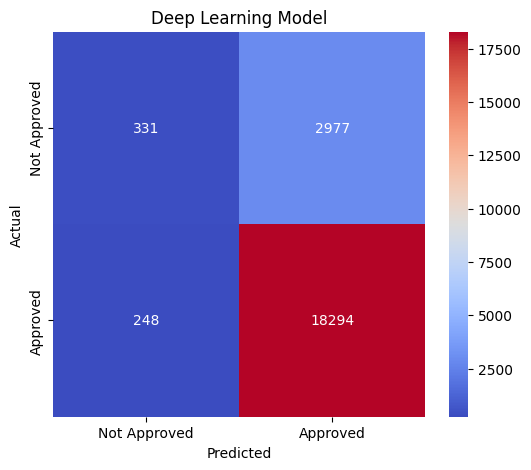

In [208]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_prediction)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True,
    fmt='d', cmap='coolwarm',
    xticklabels=['Not Approved', 'Approved'],
    yticklabels=['Not Approved', 'Approved'])

plt.title("Deep Learning Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [209]:
# ROC Curve

def plot_roc(y_true, y_prob, title):

    # Convert (n,1) array to (n,)
    y_prob = y_prob.ravel()

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
    plt.plot([0,1], [0,1], 'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

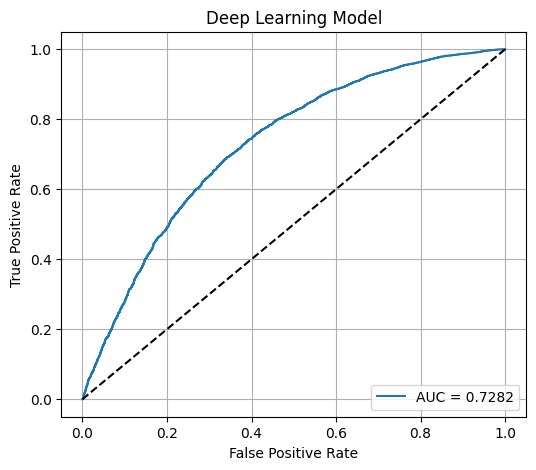

In [210]:
plot_roc(y_test, y_probability, "Deep Learning Model")

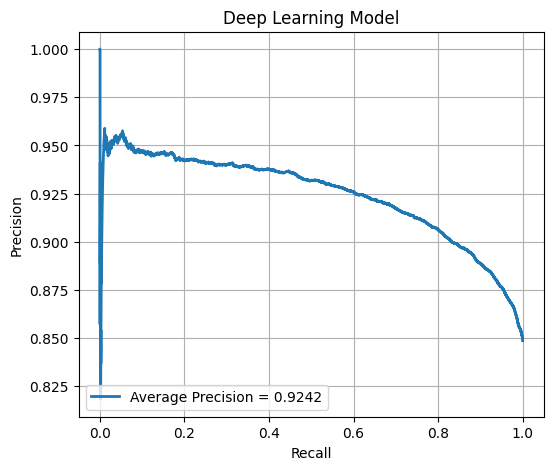

In [211]:
# Precision-Recall Curve

def plot_pr(y_true, y_prob, title):

    # Convert (n,1) array to (n,)
    y_prob = y_prob.ravel()

    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    ap = average_precision_score(y_true, y_prob)

    plt.figure(figsize=(6,5))
    plt.plot(recall, precision, linewidth=2,
             label=f"Average Precision = {ap:.4f}")

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(title)
    plt.legend(loc="lower left")
    plt.grid(True)
    plt.show()
plot_pr(y_test, y_probability, "Deep Learning Model")

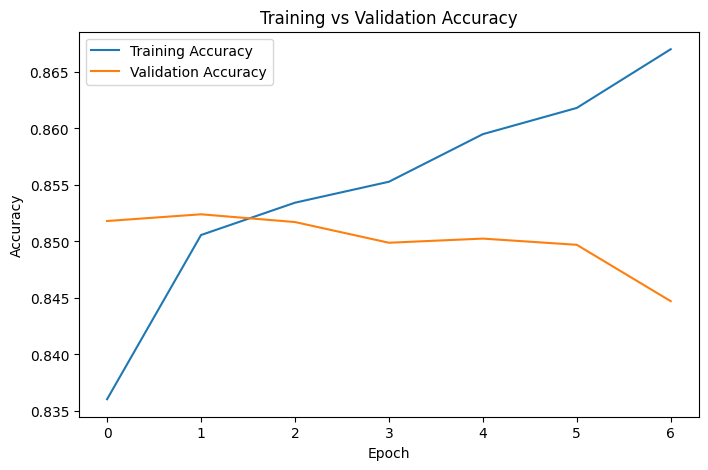

In [212]:
# Training History

plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()